In [2]:
import pandas as pd

# Load dataset
data = pd.read_csv(r"C:\ALL PROJECTS\Data analyst\walmart sales\WalmartSalesData.csv (1).csv")

# Quick check
print(data.head())
print(data.info())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total  \
0       Health and beauty       74.69         7  26.1415  548.9715   
1  Electronic accessories       15.28         5   3.8200   80.2200   
2      Home and lifestyle       46.33         7  16.2155  340.5255   
3       Health and beauty       58.22         8  23.2880  489.0480   
4       Sports and travel       86.31         7  30.2085  634.3785   

         Date      Time      Payment    cogs  gross margin percentage  \
0  2019-01-05  13:08:00      Ewallet  522.83                 4.761905   
1  2019-03-08  10:29:00         Cash   76.40                 4.761905   
2  2019-03-

In [4]:

data['Date'] = pd.to_datetime(data['Date'])

data['DateTime'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'])

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['Weekday'] = data['Date'].dt.day_name()

data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Payment,cogs,gross margin percentage,gross income,Rating,DateTime,Year,Month,Day,Weekday
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00,2019,1,5,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00,2019,3,8,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00,2019,3,3,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00,2019,1,27,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00,2019,2,8,Friday


In [5]:

print(data.isnull().sum())


print("Duplicates:", data.duplicated().sum())

data = data.drop_duplicates()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
DateTime                   0
Year                       0
Month                      0
Day                        0
Weekday                    0
dtype: int64
Duplicates: 0


C:\Users\rajak\AppData\Local\Temp\ipykernel_24696\2115003715.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_sales.index, y=branch_sales.values, palette='viridis')


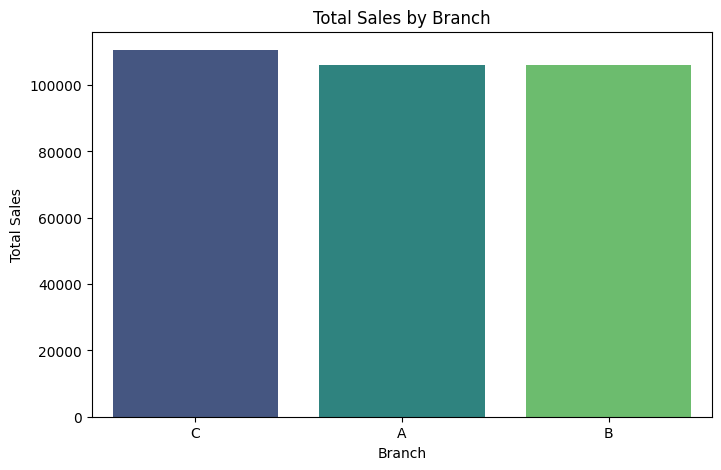

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

branch_sales = data.groupby('Branch')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=branch_sales.index, y=branch_sales.values, palette='viridis')
plt.title("Total Sales by Branch")
plt.ylabel("Total Sales")
plt.show()

C:\Users\rajak\AppData\Local\Temp\ipykernel_24696\3638983972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette='magma')


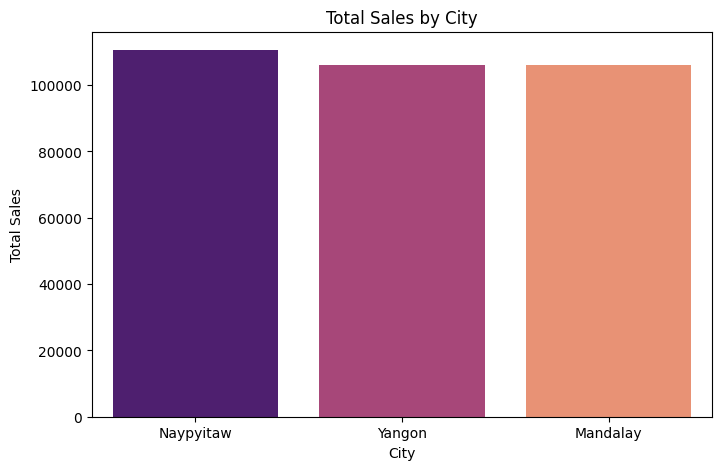

In [7]:
city_sales = data.groupby('City')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=city_sales.index, y=city_sales.values, palette='magma')
plt.title("Total Sales by City")
plt.ylabel("Total Sales")
plt.show()

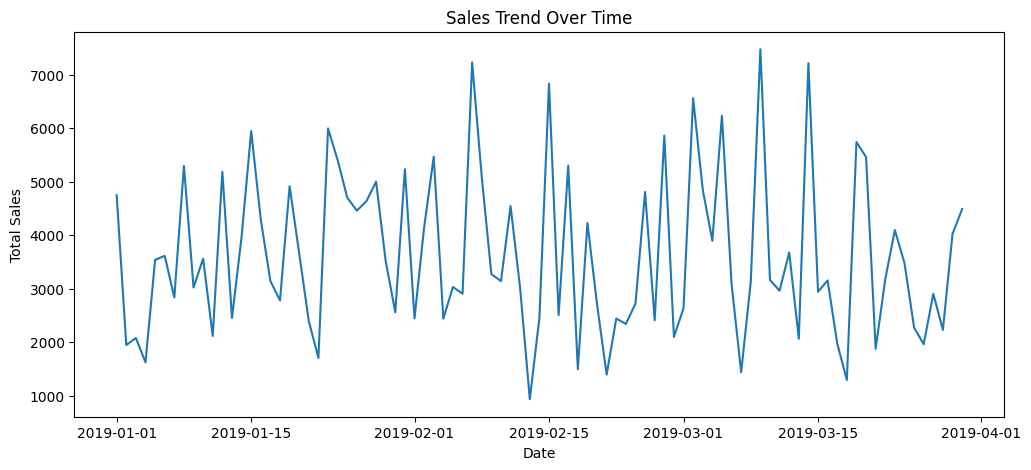

In [9]:
weekly_sales = data.groupby('Date')['Total'].sum()

plt.figure(figsize=(12,5))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

C:\Users\rajak\AppData\Local\Temp\ipykernel_24696\2027738081.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_sales.index, y=customer_sales.values, palette='Set2')


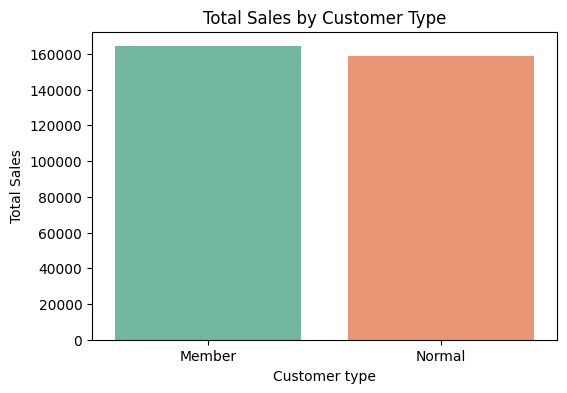

In [10]:
customer_sales = data.groupby('Customer type')['Total'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=customer_sales.index, y=customer_sales.values, palette='Set2')
plt.title("Total Sales by Customer Type")
plt.ylabel("Total Sales")
plt.show()

C:\Users\rajak\AppData\Local\Temp\ipykernel_24696\2183693940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_sales.index, y=payment_sales.values, palette='Set3')


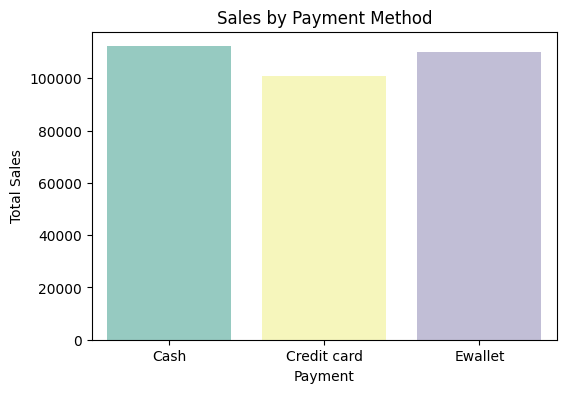

In [11]:
payment_sales = data.groupby('Payment')['Total'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=payment_sales.index, y=payment_sales.values, palette='Set3')
plt.title("Sales by Payment Method")
plt.ylabel("Total Sales")
plt.show()

C:\Users\rajak\AppData\Local\Temp\ipykernel_24696\3614976417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='pastel')


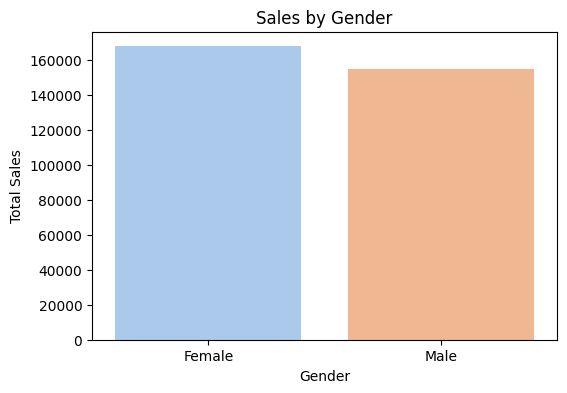

In [12]:
gender_sales = data.groupby('Gender')['Total'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='pastel')
plt.title("Sales by Gender")
plt.ylabel("Total Sales")
plt.show()

C:\Users\rajak\AppData\Local\Temp\ipykernel_24696\1138735182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_profit.index, y=branch_profit.values, palette='Blues')


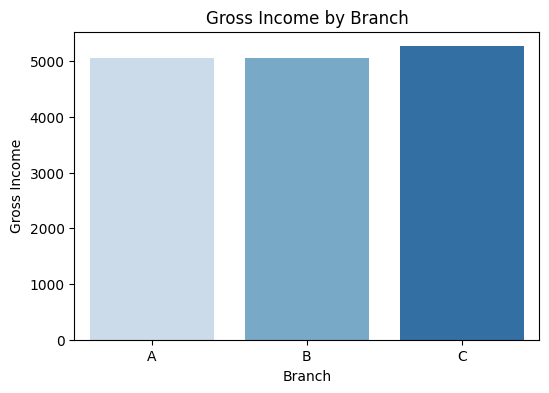

In [13]:
# Gross income per branch
branch_profit = data.groupby('Branch')['gross income'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=branch_profit.index, y=branch_profit.values, palette='Blues')
plt.title("Gross Income by Branch")
plt.ylabel("Gross Income")
plt.show()

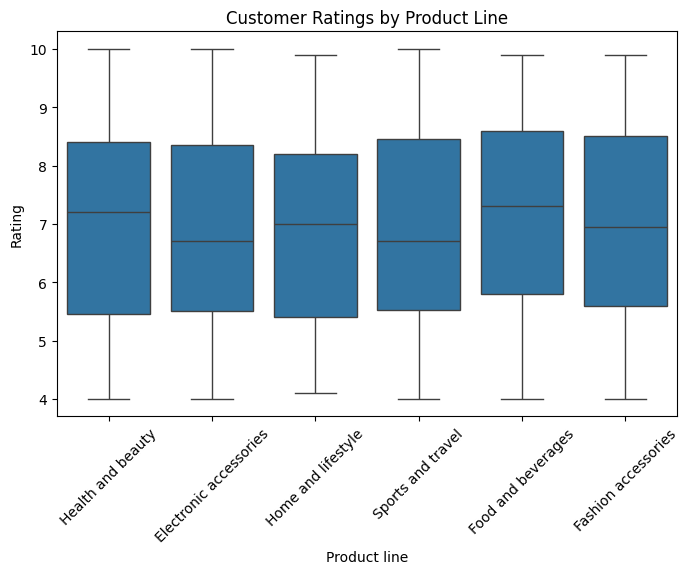

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Product line', y='Rating', data=data)
plt.xticks(rotation=45)
plt.title("Customer Ratings by Product Line")
plt.show()

In [15]:
from prophet import Prophet
import pandas as pd

# Aggregate total sales by date
sales_df = data.groupby('Date')['Total'].sum().reset_index()
sales_df.rename(columns={'Date':'ds','Total':'y'}, inplace=True)

# Quick check
sales_df.head()

c:\Users\rajak\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ds,y
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


In [16]:
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(sales_df)

21:19:28 - cmdstanpy - INFO - Chain [1] start processing
21:19:29 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
# Predict next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Check forecast
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
114,2019-04-25,21415.376888,19502.252966,23235.952260
115,2019-04-26,22851.241545,21071.364801,24661.791515
116,2019-04-27,25326.658413,23615.460836,27182.222813
117,2019-04-28,26211.911717,24486.696183,27945.768869
118,2019-04-29,27108.038408,25275.249296,28964.920636


In [19]:

from prophet.plot import plot_plotly, plot_components_plotly

import plotly.offline as py
import plotly.graph_objects as go

# Interactive forecast plot
fig = plot_plotly(model, forecast)
py.iplot(fig)

# Seasonal components
fig2 = plot_components_plotly(model, forecast)
py.iplot(fig2)

In [23]:
from sklearn.preprocessing import LabelEncoder

df = data.copy()
categorical_cols = ['Branch','City','Customer type','Gender','Product line','Payment']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
    
from sklearn.model_selection import train_test_split

X = df[['Branch','City','Customer type','Gender','Product line','Unit price','Quantity','Payment']]
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# Calculate RMSE manually
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

MAE: 5.35005187499997
RMSE: 8.061896468478439


In [31]:

import plotly.express as px
branch_sales = data.groupby('Branch')['Total'].sum().reset_index()
fig = px.bar(branch_sales, x='Branch', y='Total', title='Total Sales by Branch', color='Branch')
fig.show()


In [33]:
# Total sales by branch
branch_sales = data.groupby('Branch')['Total'].sum().reset_index()

# Total sales by product line
product_sales = data.groupby('Product line')['Total'].sum().reset_index()

# Daily sales trend
daily_sales = data.groupby('Date')['Total'].sum().reset_index()

# Sales by branch and customer type
cust_branch_sales = data.groupby(['Branch','Customer type'])['Total'].sum().reset_index()

# Sales by payment method
payment_sales = data.groupby('Payment')['Total'].sum().reset_index()


In [52]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

# Load data
data = pd.read_csv(r"C:\ALL PROJECTS\Data analyst\walmart sales\WalmartSalesData.csv (1).csv")
data['Date'] = pd.to_datetime(data['Date'])

# Aggregations
branch_sales = data.groupby('Branch')['Total'].sum().reset_index()
product_sales = data.groupby('Product line')['Total'].sum().reset_index()
daily_sales = data.groupby('Date')['Total'].sum().reset_index()
cust_branch_sales = data.groupby(['Branch','Customer type'])['Total'].sum().reset_index()
payment_sales = data.groupby('Payment')['Total'].sum().reset_index()

# Create subplot layout with domain for Pie
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"type":"xy"}, {"type":"domain"}],    # Pie in col 2, row 1
           [{"type":"xy"}, {"type":"xy"}],
           [{"type":"xy"}, {"type":"xy"}]],
    subplot_titles=(
        "Total Sales by Branch", 
        "Sales by Product Line",
        "Daily Sales Trend", 
        "Sales by Branch & Customer Type",
        "Sales vs Customer Rating",
        "Sales by Payment Method"
    ),
    vertical_spacing=0.12
)

# Row 1, Col 1: Branch Sales
fig.add_trace(
    go.Bar(x=branch_sales['Branch'], y=branch_sales['Total'], marker_color='teal', name='Branch Sales'),
    row=1, col=1
)

# Row 1, Col 2: Product Sales (Pie)
fig.add_trace(
    go.Pie(labels=product_sales['Product line'], values=product_sales['Total'], name='Product Line Sales', hole=0.3),
    row=1, col=2
)

# Row 2, Col 1: Daily Sales Trend
fig.add_trace(
    go.Scatter(x=daily_sales['Date'], y=daily_sales['Total'], mode='lines+markers', name='Daily Sales', line=dict(color='orange')),
    row=2, col=1
)

# Row 2, Col 2: Sales by Branch & Customer Type
for cust_type in cust_branch_sales['Customer type'].unique():
    temp = cust_branch_sales[cust_branch_sales['Customer type'] == cust_type]
    fig.add_trace(
        go.Bar(x=temp['Branch'], y=temp['Total'], name=cust_type),
        row=2, col=2
    )

# Row 3, Col 1: Sales vs Rating
fig.add_trace(
    go.Scatter(x=data['Total'], y=data['Rating'], mode='markers',
               marker=dict(size=data['Quantity'], color=data['Quantity'], showscale=True),
               text=data['Product line'], name='Sales vs Rating'),
    row=3, col=1
)

# Row 3, Col 2: Sales by Payment Method
fig.add_trace(
    go.Bar(x=payment_sales['Payment'], y=payment_sales['Total'], marker_color='purple', name='Payment Method'),
    row=3, col=2
)

# Layout update
fig.update_layout(height=1000, width=1200, title_text="Supermarket Sales Dashboard", showlegend=True)
fig.show()

In [38]:
total_sales = data['Total'].sum()
total_transactions = len(data)
avg_rating = data['Rating'].mean()
total_profit = data['gross income'].sum()

print("Total Sales:", total_sales)
print("Transactions:", total_transactions)
print("Avg Rating:", avg_rating)
print("Total Profit:", total_profit)

Total Sales: 322966.749
Transactions: 1000
Avg Rating: 6.9727
Total Profit: 15379.368999999999


In [39]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_sales,
    title={"text": "Total Sales"},
    domain={'x': [0, 0.25], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=total_transactions,
    title={"text": "Transactions"},
    domain={'x': [0.25, 0.5], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=avg_rating,
    title={"text": "Avg Rating"},
    domain={'x': [0.5, 0.75], 'y': [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=total_profit,
    title={"text": "Total Profit"},
    domain={'x': [0.75, 1], 'y': [0, 1]}
))

fig.update_layout(title="KPI Dashboard")
fig.show()

In [40]:
import plotly.express as px

fig = px.bar(data, x='Branch', y='Total', color='Product line',
             title='Sales by Branch')

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(label="All",
                     method="update",
                     args=[{"visible": [True]*len(fig.data)}]),
            ],
            direction="down"
        )
    ]
)

fig.show()

In [43]:
# Prepare actual sales data for Prophet
forecast_df = data.groupby('Date')['Total'].sum().reset_index()

# Rename columns for Prophet
forecast_df.rename(columns={'Date': 'ds', 'Total': 'y'}, inplace=True)

# Check
forecast_df.head()

,ds,y
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


In [44]:
# Actual
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat'],
    name='Predicted Sales',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_df['ds'],
    y=forecast_df['y'],
    name='Actual Sales',
    line=dict(color='green')
))

fig.show()

In [46]:
# Make sure Date is datetime
data['Date'] = pd.to_datetime(data['Date'])

# Create Weekday column
data['Weekday'] = data['Date'].dt.day_name()

# Top Product
top_product = data.groupby('Product line')['Total'].sum().idxmax()

# Best Branch
best_branch = data.groupby('Branch')['Total'].sum().idxmax()

# Peak Day
peak_day = data.groupby('Weekday')['Total'].sum().idxmax()

print("Top Product:", top_product)
print("Best Branch:", best_branch)
print("Peak Sales Day:", peak_day)

Top Product: Food and beverages
Best Branch: C
Peak Sales Day: Saturday


In [47]:
# Top Product with value
product_sales = data.groupby('Product line')['Total'].sum()
top_product = product_sales.idxmax()
top_product_value = product_sales.max()

# Best Branch with value
branch_sales = data.groupby('Branch')['Total'].sum()
best_branch = branch_sales.idxmax()
best_branch_value = branch_sales.max()

# Peak Day with value
weekday_sales = data.groupby('Weekday')['Total'].sum()
peak_day = weekday_sales.idxmax()
peak_day_value = weekday_sales.max()

print(f"Top Product: {top_product} (Sales: {top_product_value:.2f})")
print(f"Best Branch: {best_branch} (Sales: {best_branch_value:.2f})")
print(f"Peak Sales Day: {peak_day} (Sales: {peak_day_value:.2f})")

Top Product: Food and beverages (Sales: 56144.84)
Best Branch: C (Sales: 110568.71)
Peak Sales Day: Saturday (Sales: 56120.81)


In [48]:
import plotly.express as px

fig = px.bar(product_sales.reset_index(), 
             x='Product line', y='Total',
             title='Sales by Product Line')

fig.show()

In [ ]:
from dash import Dash, dcc, html, Input, Output
import pandas as pd
import plotly.express as px


data = pd.read_csv(r"C:\ALL PROJECTS\Data analyst\walmart sales\WalmartSalesData.csv (1).csv")
data['Date'] = pd.to_datetime(data['Date'])


app = Dash(__name__)


app.layout = html.Div([

    html.H1("📊 Sales Dashboard", style={'textAlign': 'center'}),

    dcc.Dropdown(
        id='branch_filter',
        options=[{'label': b, 'value': b} for b in data['Branch'].unique()],
        value=data['Branch'].unique()[0],
        clearable=False
    ),
    
    html.Div(id='kpi_cards', style={'display': 'flex', 'justifyContent': 'space-around'}),

    
    dcc.Graph(id='bar_chart'),
    dcc.Graph(id='pie_chart'),
    dcc.Graph(id='line_chart')

])


@app.callback(
    [Output('bar_chart', 'figure'),
     Output('pie_chart', 'figure'),
     Output('line_chart', 'figure'),
     Output('kpi_cards', 'children')],
    [Input('branch_filter', 'value')]
)
def update_dashboard(selected_branch):

    
    df = data[data['Branch'] == selected_branch]

    total_sales = df['Total'].sum()
    avg_rating = df['Rating'].mean()
    total_transactions = len(df)

    kpi = [
        html.Div(f"💰 Sales: {total_sales:.2f}"),
        html.Div(f"⭐ Rating: {avg_rating:.2f}"),
        html.Div(f"🧾 Transactions: {total_transactions}")
    ]

    
    bar_fig = px.bar(df, x='Product line', y='Total', title='Sales by Product')

    
    pie_fig = px.pie(df, names='Payment', values='Total', title='Payment Distribution')

    
    daily = df.groupby('Date')['Total'].sum().reset_index()
    line_fig = px.line(daily, x='Date', y='Total', title='Sales Trend')

    return bar_fig, pie_fig, line_fig, kpi


app.run(debug=True)